In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape # Observamos el tamaño de del dataset

(7043, 21)

In [3]:
df.info() # Informacion general

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.isnull().sum().sort_values(ascending=False) # Buscamos valores faltantes

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df["Churn"].value_counts() #Contamos cantidad de Churns

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
df["Churn"].value_counts(normalize=True) * 100  #Porcentaje de churns

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [7]:
df.columns.to_list() # Observamos las columnas

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [8]:
df["TotalCharges"].head(20) # Revisamos total charges, porque esta como str y no como float

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: str

In [9]:
df["TotalCharges"].describe()

count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object

In [10]:
df[df["TotalCharges"] == " "] # Observamos cuantas filas vacias hay en total charges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [11]:
len(df[df["TotalCharges"] == " "]) # Contamos cuantas filas vacias hay

11

In [12]:
df[df["TotalCharges"] == " "]["tenure"].value_counts()

tenure
0    11
Name: count, dtype: int64

In [13]:
df[df["TotalCharges"] == " "][
    ["tenure", "MonthlyCharges", "TotalCharges"]
]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [14]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", 0) #Remplazamos espacios vacios por 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"]) #Lo convertimos a valor numerico

In [15]:
df["TotalCharges"].dtype #Verificamos

dtype('float64')

Ahora vamos a buscar que variables estan relacionadas con el churn = Perdida de clientes

In [16]:
# Churn por tipo de contrato
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [17]:
# Churn por servicio de internet
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [18]:
# Churn por soporte técnico
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [19]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194




Los clientes con contrato mensual abandonan:

4 veces más que los de 1 año
15 veces más que los de 2 años

Los clientes que tienen soporte técnico abandonan mucho menos.

La seguridad online muestra un patrón similar

Los clientes que utilizan más servicios tienen menor probabilidad de abandonar.

Fiber Optic tiene un churn inesperadamente alto



In [20]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [21]:
df.groupby("Churn")["TotalCharges"].mean()

Churn
No     2549.911442
Yes    1531.796094
Name: TotalCharges, dtype: float64

In [22]:
df.groupby("Churn")["MonthlyCharges"].sum()

Churn
No     316985.75
Yes    139130.85
Name: MonthlyCharges, dtype: float64

Los clientes que se van pagan MÁS por mes

| Churn | MonthlyCharges promedio |
| ----- | ----------------------- |
| No    | 61.27                   |
| Yes   | 74.44                   |

Los clientes que se quedan han gastado mucho más históricamente

| Churn | TotalCharges promedio |
| ----- | --------------------- |
| No    | 2549.91               |
| Yes   | 1531.80               |



In [23]:
# La antiguedad influye?
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [24]:
pd.qcut(df["tenure"], q=4)

0       (-0.001, 9.0]
1        (29.0, 55.0]
2       (-0.001, 9.0]
3        (29.0, 55.0]
4       (-0.001, 9.0]
            ...      
7038      (9.0, 29.0]
7039     (55.0, 72.0]
7040      (9.0, 29.0]
7041    (-0.001, 9.0]
7042     (55.0, 72.0]
Name: tenure, Length: 7043, dtype: category
Categories (4, interval[float64, right]): [(-0.001, 9.0] < (9.0, 29.0] < (29.0, 55.0] < (55.0, 72.0]]

In [25]:
tenure_bins = pd.qcut(df["tenure"], q=4)

pd.crosstab(
    tenure_bins,
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
tenure,,
"(-0.001, 9.0]",50.215750,49.784250
"(9.0, 29.0]",71.661808,28.338192
"(29.0, 55.0]",81.151832,18.848168
"(55.0, 72.0]",92.250712,7.749288


0-9 meses      → 49.8% churn
9-29 meses     → 28.3% churn
29-55 meses    → 18.8% churn
55-72 meses    → 7.7% churn

In [26]:
insights = []

In [27]:
pd.crosstab(
    [df["Contract"], tenure_bins],
    df["Churn"],
    normalize="index"
) * 100

Churn                                 No        Yes
Contract       tenure                              
Month-to-month (-0.001, 9.0]   47.113164  52.886836
               (9.0, 29.0]     62.540984  37.459016
               (29.0, 55.0]    67.170330  32.829670
               (55.0, 72.0]    77.948718  22.051282
One year       (-0.001, 9.0]   90.410959   9.589041
               (9.0, 29.0]     92.134831   7.865169
               (29.0, 55.0]    87.788779  12.211221
               (55.0, 72.0]    86.986301  13.013699
Two year       (-0.001, 9.0]  100.000000   0.000000
               (9.0, 29.0]     99.280576   0.719424
               (29.0, 55.0]    97.142857   2.857143
               (55.0, 72.0]    96.791444   3.208556

In [28]:
df_ml = df.copy()

In [29]:
df_ml["Churn"] = df_ml["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [30]:
print(
    df_ml.groupby("Churn")["tenure"]
    .agg(["count", "mean", "median"])
)

       count       mean  median
Churn                          
0       5174  37.569965    38.0
1       1869  17.979133    10.0


In [31]:
print(
    df_ml.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median"])
)

       count       mean  median
Churn                          
0       5174  61.265124  64.425
1       1869  74.441332  79.650


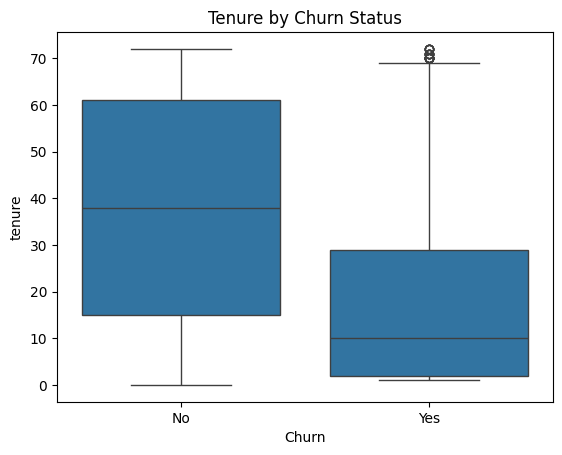

In [32]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure by Churn Status")
plt.show()

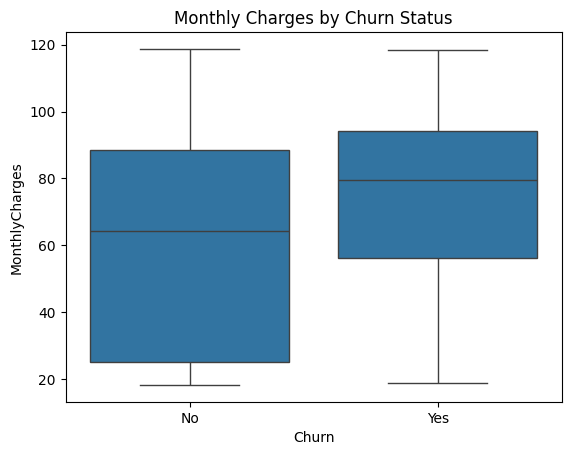

In [33]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.show()

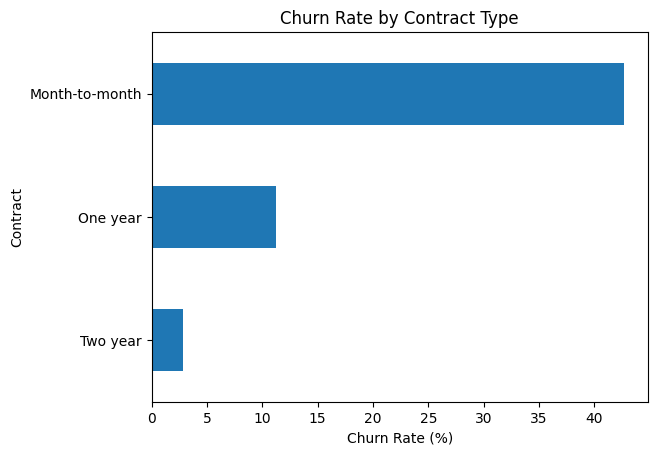

In [34]:
contract_churn = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
)

contract_churn["Yes"].sort_values().plot(
    kind="barh"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Churn Rate (%)")
plt.show()

In [35]:
categorical_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [36]:
for col in categorical_cols:
    churn_rate = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100
    
    print(f"\n{"="*50}")
    print(col)
    print(churn_rate["Yes"].sort_values(ascending=False))
    
    


gender
gender
Female    26.920872
Male      26.160338
Name: Yes, dtype: float64

SeniorCitizen
SeniorCitizen
1    41.681261
0    23.606168
Name: Yes, dtype: float64

Partner
Partner
No     32.957979
Yes    19.664903
Name: Yes, dtype: float64

Dependents
Dependents
No     31.279140
Yes    15.450237
Name: Yes, dtype: float64

PhoneService
PhoneService
Yes    26.709637
No     24.926686
Name: Yes, dtype: float64

MultipleLines
MultipleLines
Yes                 28.609896
No                  25.044248
No phone service    24.926686
Name: Yes, dtype: float64

InternetService
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Yes, dtype: float64

OnlineSecurity
OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Yes, dtype: float64

OnlineBackup
OnlineBackup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Yes, dtype: float64


In [37]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700
